In [1]:
import pandas as pd, numpy as np, sklearn, matplotlib, seaborn as sns
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

print("pandas", pd.__version__, "| sklearn", sklearn.__version__, "| numpy", np.__version__)

df = pd.read_csv("data/customer_churn_advanced_dataset.csv")
df_raw = df.copy()      # untouched backup

print(df.shape)
df.head()

pandas 3.0.6 | sklearn 1.9.1 | numpy 2.5.3
(1200, 20)


,customer_id,age,tenure_months,contract_type,internet_service,region,monthly_charges,total_charges,payment_method,paperless_billing,dependents,support_plan,tech_support,complaints_last_12m,late_payments_last_12m,satisfaction_score,monthly_usage_gb,discount_pct,senior_citizen,churn
0,CUST100001,23,64,One year,Fiber optic,Eastern,48.36,3082.83,Mailed check,No,No,No,No,0,0,6.2,16.4,5.61,0,1
1,CUST100002,62,35,One year,DSL,Central,51.34,1585.19,Electronic check,Yes,No,Yes,No,1,1,7.4,38.1,0.00,0,1
2,CUST100003,55,71,Month-to-month,DSL,North Central,130.98,8564.89,Bank transfer,No,No,No,No,0,1,8.2,NaN,22.92,0,1
3,CUST100004,43,55,Month-to-month,Fiber optic,Western,115.24,6390.85,Credit card,Yes,No,No,No,0,1,9.8,70.1,9.66,0,1
4,CUST100005,43,47,Month-to-month,Fiber optic,Sabaragamuwa,62.12,2540.63,Electronic check,Yes,No,No,No,3,0,8.5,144.2,11.20,0,1


In [2]:
df.info()

missing = df.isna().sum()
missing_pct = (df.isna().mean() * 100).round(2)
pd.DataFrame({"missing": missing, "pct": missing_pct}).query("missing > 0")

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             1200 non-null   str    
 1   age                     1200 non-null   int64  
 2   tenure_months           1200 non-null   int64  
 3   contract_type           1200 non-null   str    
 4   internet_service        1200 non-null   str    
 5   region                  1200 non-null   str    
 6   monthly_charges         1170 non-null   float64
 7   total_charges           1176 non-null   float64
 8   payment_method          1200 non-null   str    
 9   paperless_billing       1200 non-null   str    
 10  dependents              1200 non-null   str    
 11  support_plan            1200 non-null   str    
 12  tech_support            1200 non-null   str    
 13  complaints_last_12m     1200 non-null   int64  
 14  late_payments_last_12m  1200 non-null   int64  
 15

,missing,pct
monthly_charges,30,2.5
total_charges,24,2.0
satisfaction_score,48,4.0
monthly_usage_gb,36,3.0


In [3]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate customer IDs:", df.customer_id.duplicated().sum())
print("Unique IDs:", df.customer_id.nunique(), "of", len(df))

Duplicate rows: 0
Duplicate customer IDs: 0
Unique IDs: 1200 of 1200


churn
1    1036
0     164
Name: count, dtype: int64
churn
1    0.863
0    0.137
Name: proportion, dtype: float64


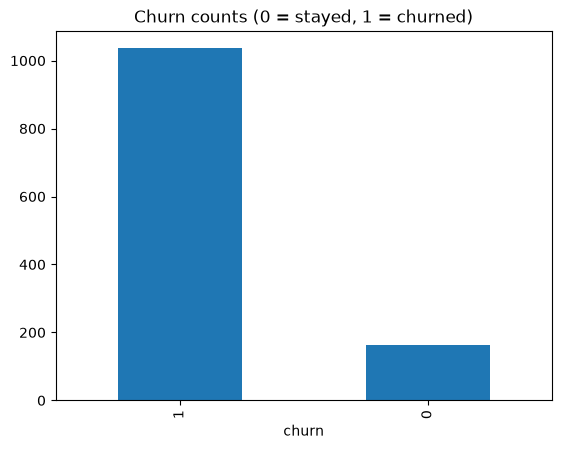

In [4]:
print(df.churn.value_counts())
print(df.churn.value_counts(normalize=True).round(3))
df.churn.value_counts().plot(kind="bar", title="Churn counts (0 = stayed, 1 = churned)")
plt.show()

In [5]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
age,1200.0,46.75,16.67,18.00,32.00,47.00,61.00,75.00
tenure_months,1200.0,36.27,20.92,1.00,18.00,35.00,54.00,72.00
monthly_charges,1170.0,71.43,25.82,20.00,54.44,71.82,87.00,235.01
total_charges,1176.0,2568.01,1807.26,22.73,1119.23,2244.46,3752.03,8853.76
complaints_last_12m,1200.0,0.71,0.85,0.00,0.00,1.00,1.00,5.00
late_payments_last_12m,1200.0,0.84,0.89,0.00,0.00,1.00,1.00,4.00
satisfaction_score,1152.0,6.74,1.78,1.00,5.60,6.75,8.00,10.00
monthly_usage_gb,1164.0,66.93,39.60,2.00,41.18,66.40,89.32,466.90
discount_pct,1200.0,9.16,6.61,0.00,3.58,8.72,13.70,32.89
senior_citizen,1200.0,0.17,0.38,0.00,0.00,0.00,0.00,1.00


In [6]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
age,1200.0,46.75,16.67,18.00,32.00,47.00,61.00,75.00
tenure_months,1200.0,36.27,20.92,1.00,18.00,35.00,54.00,72.00
monthly_charges,1170.0,71.43,25.82,20.00,54.44,71.82,87.00,235.01
total_charges,1176.0,2568.01,1807.26,22.73,1119.23,2244.46,3752.03,8853.76
complaints_last_12m,1200.0,0.71,0.85,0.00,0.00,1.00,1.00,5.00
late_payments_last_12m,1200.0,0.84,0.89,0.00,0.00,1.00,1.00,4.00
satisfaction_score,1152.0,6.74,1.78,1.00,5.60,6.75,8.00,10.00
monthly_usage_gb,1164.0,66.93,39.60,2.00,41.18,66.40,89.32,466.90
discount_pct,1200.0,9.16,6.61,0.00,3.58,8.72,13.70,32.89
senior_citizen,1200.0,0.17,0.38,0.00,0.00,0.00,0.00,1.00


In [7]:
num_cols = ["monthly_charges", "total_charges", "monthly_usage_gb", "discount_pct"]
for c in num_cols:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
    n = ((df[c] < low) | (df[c] > high)).sum()
    print(f"{c}: {n} outliers outside [{low:.1f}, {high:.1f}]")

monthly_charges: 12 outliers outside [5.6, 135.8]
total_charges: 14 outliers outside [-2830.0, 7701.2]
monthly_usage_gb: 5 outliers outside [-31.0, 161.6]
discount_pct: 2 outliers outside [-11.6, 28.9]


In [8]:
ratio = df.total_charges / (df.monthly_charges * df.tenure_months)
print(ratio.describe().round(3))
suspicious = df[(ratio < 0.7) | (ratio > 1.3)]
print("Suspicious rows:", len(suspicious))
suspicious[["customer_id","tenure_months","monthly_charges","total_charges"]].head(10)

count    1147.000
mean        0.997
std         0.098
min         0.241
25%         0.923
50%         1.002
75%         1.074
max         1.150
dtype: float64
Suspicious rows: 5


,customer_id,tenure_months,monthly_charges,total_charges
22,CUST100023,70,185.81,4627.17
360,CUST100361,21,217.83,1397.02
604,CUST100605,10,193.06,473.68
635,CUST100636,10,235.01,567.41
650,CUST100651,6,203.65,439.24


In [9]:
for c in df.select_dtypes(include="str").columns.drop("customer_id"):
    print(c, "->", df[c].value_counts().to_dict())

contract_type -> {'Month-to-month': 708, 'One year': 303, 'Two year': 189}
internet_service -> {'Fiber optic': 621, 'DSL': 430, 'No': 149}
region -> {'Western': 147, 'Central': 144, 'Northern': 138, 'Eastern': 136, 'Southern': 136, 'Uva': 130, 'North Central': 126, 'Sabaragamuwa': 125, 'North Western': 118}
payment_method -> {'Electronic check': 392, 'Credit card': 346, 'Bank transfer': 303, 'Mailed check': 159}
paperless_billing -> {'Yes': 784, 'No': 416}
dependents -> {'No': 840, 'Yes': 360}
support_plan -> {'No': 691, 'Yes': 509}
tech_support -> {'No': 726, 'Yes': 474}


In [10]:
df["implied_monthly"] = df.total_charges / df.tenure_months

q1, q3 = df.monthly_charges.quantile([0.25, 0.75])
high = q3 + 1.5*(q3 - q1)
out = df[df.monthly_charges > high]
out[["customer_id","tenure_months","monthly_charges","implied_monthly","total_charges","churn"]]

,customer_id,tenure_months,monthly_charges,implied_monthly,total_charges,churn
22,CUST100023,70,185.81,66.102429,4627.17,0
174,CUST100175,64,137.06,135.046875,8643.00,1
360,CUST100361,21,217.83,66.524762,1397.02,0
452,CUST100453,4,141.94,138.127500,552.51,1
604,CUST100605,10,193.06,47.368000,473.68,1
605,CUST100606,4,139.43,128.332500,513.33,0
635,CUST100636,10,235.01,56.741000,567.41,1
650,CUST100651,6,203.65,73.206667,439.24,1
889,CUST100890,2,140.58,161.640000,323.28,1
978,CUST100979,46,136.90,156.366739,7192.87,1


In [11]:
ratio = df.total_charges / (df.monthly_charges * df.tenure_months)
df["charge_inconsistent"] = ((ratio < 0.7) | (ratio > 1.3)).astype(int)
print(df.charge_inconsistent.sum())   # expect 5

5


In [12]:
for c in ["satisfaction_score","monthly_usage_gb","monthly_charges","total_charges"]:
    print(c, df.groupby(df[c].isna()).churn.mean().round(3).to_dict())

satisfaction_score {False: 0.862, True: 0.896}
monthly_usage_gb {False: 0.864, True: 0.833}
monthly_charges {False: 0.863, True: 0.867}
total_charges {False: 0.862, True: 0.917}


In [13]:
ratio = df.total_charges / (df.monthly_charges * df.tenure_months)
df["charge_inconsistent"] = ((ratio < 0.7) | (ratio > 1.3)).astype(int)
df = df.drop(columns=["implied_monthly"], errors="ignore")   # helper column, not a feature
print(df.charge_inconsistent.sum())    # expect 5

import os; os.makedirs("outputs", exist_ok=True)
df.to_csv("outputs/02_cleaned_dataset.csv", index=False)

5


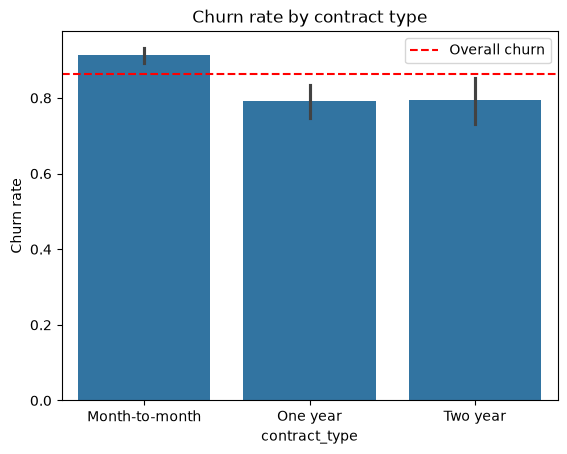

In [14]:
sns.barplot(data=df, x="contract_type", y="churn", order=["Month-to-month","One year","Two year"])
plt.axhline(df.churn.mean(), color="red", ls="--", label="Overall churn")
plt.ylabel("Churn rate"); plt.title("Churn rate by contract type"); plt.legend()
plt.savefig("outputs/chart1_contract.png", dpi=150, bbox_inches="tight"); plt.show()

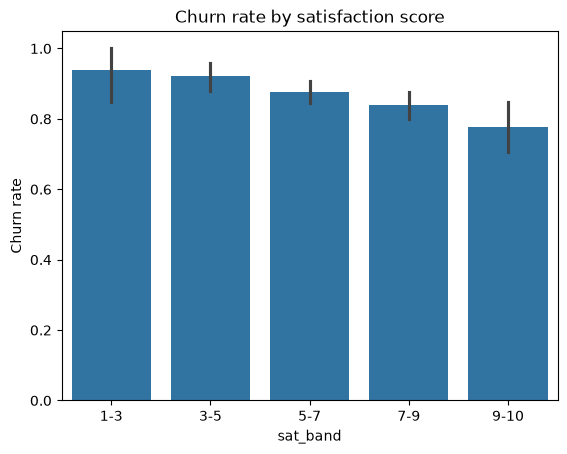

In [15]:
df["sat_band"] = pd.cut(df.satisfaction_score, [0,3,5,7,9,10], labels=["1-3","3-5","5-7","7-9","9-10"])
sns.barplot(data=df, x="sat_band", y="churn")
plt.ylabel("Churn rate"); plt.title("Churn rate by satisfaction score")
plt.savefig("outputs/chart2_satisfaction.png", dpi=150, bbox_inches="tight"); plt.show()

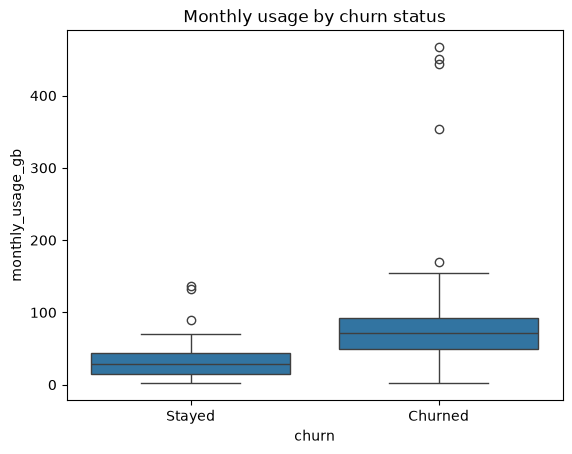

In [16]:
sns.boxplot(data=df, x="churn", y="monthly_usage_gb")
plt.xticks([0,1], ["Stayed","Churned"]); plt.title("Monthly usage by churn status")
plt.savefig("outputs/chart3_usage.png", dpi=150, bbox_inches="tight"); plt.show()

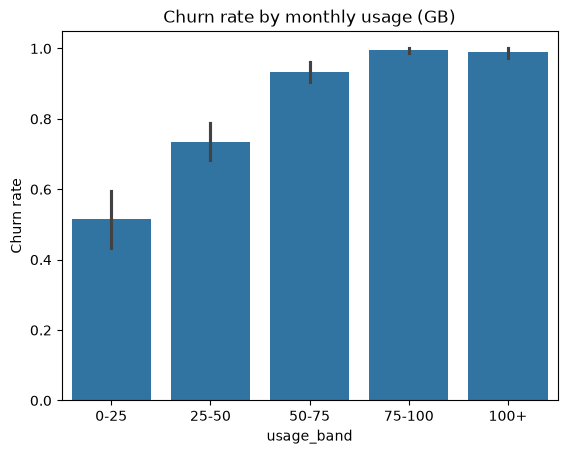

In [17]:
df["usage_band"] = pd.cut(df.monthly_usage_gb, [0,25,50,75,100,500],
                          labels=["0-25","25-50","50-75","75-100","100+"])
sns.barplot(data=df, x="usage_band", y="churn")
plt.ylabel("Churn rate"); plt.title("Churn rate by monthly usage (GB)")
plt.savefig("outputs/chart4_usage_bands.png", dpi=150, bbox_inches="tight"); plt.show()

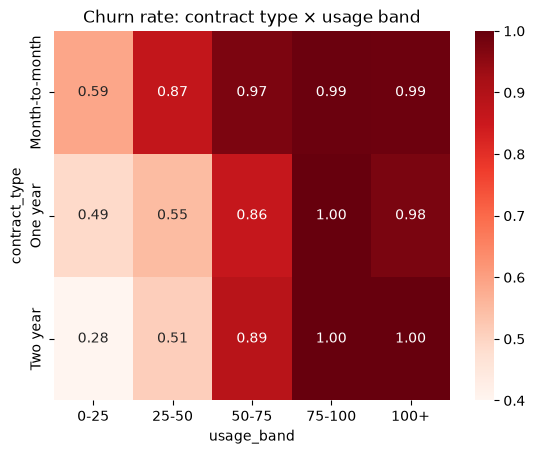

In [18]:
pivot = df.pivot_table(index="contract_type", columns="usage_band", values="churn", aggfunc="mean")
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="Reds", vmin=0.4, vmax=1)
plt.title("Churn rate: contract type × usage band")
plt.savefig("outputs/chart5_interaction.png", dpi=150, bbox_inches="tight"); plt.show()

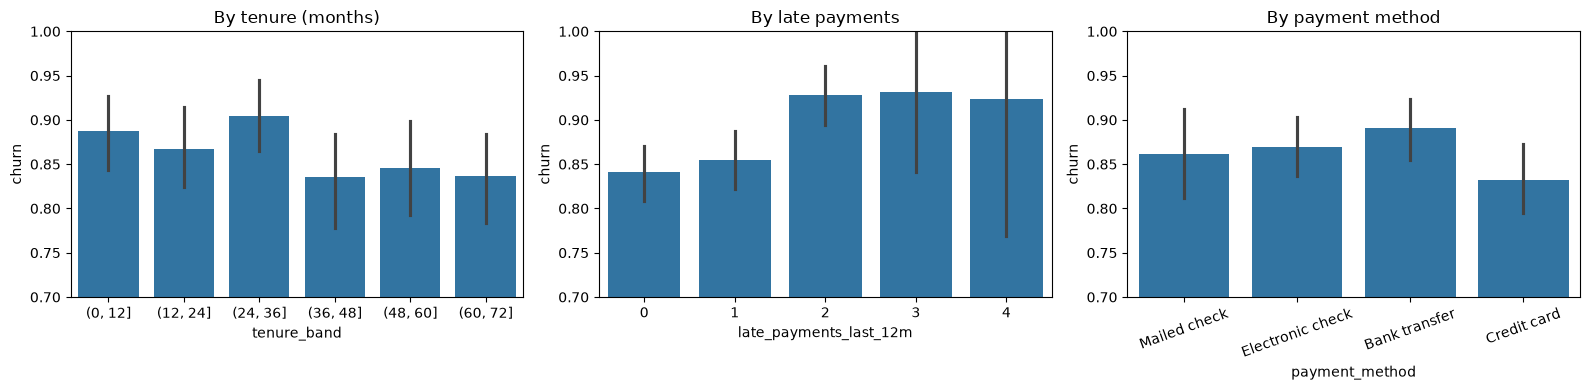

In [19]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
df["tenure_band"] = pd.cut(df.tenure_months, [0,12,24,36,48,60,72])
sns.barplot(data=df, x="tenure_band", y="churn", ax=ax[0]); ax[0].set_title("By tenure (months)")
sns.barplot(data=df, x="late_payments_last_12m", y="churn", ax=ax[1]); ax[1].set_title("By late payments")
sns.barplot(data=df, x="payment_method", y="churn", ax=ax[2]); ax[2].set_title("By payment method")
ax[2].tick_params(axis="x", rotation=20)
for a in ax: a.set_ylim(0.7, 1.0)
plt.tight_layout(); plt.savefig("outputs/chart6_tenure_late_payment.png", dpi=150, bbox_inches="tight"); plt.show()

## EDA Interpretations

1. **Contract type:** Month-to-month customers churn at ~91% vs ~79% for one- and two-year contracts, which look the same. The key split is month-to-month vs committed.
2. **Satisfaction:** Churn falls steadily from ~94% (score 1-3) to ~78% (score 9-10). A consistent but moderate effect.
3. **Usage (boxplot):** Churners have far higher usage (median ~70 GB vs ~30 GB). Heavy users leave more, which is counter-intuitive and needs checking (see leakage assumption).
4. **Usage bands:** Churn rises non-linearly from ~52% (0-25 GB) to ~99% above 75 GB, then plateaus. This is a threshold effect, so linear models may under-fit it.
5. **Contract x usage:** Contract protects light users (two-year, 0-25 GB: 28%) but not heavy users (all contracts ~99-100% above 75 GB). This is an interaction. The 28% cell has only n=18 and is indicative only.
6. **Tenure / late payments / payment method:** [fill in after chart 6: expected weak tenure effect, moderate late-payment effect, small payment-method differences]

## Unusual observations
- 5 rows have monthly_charges ~3x the value implied by total_charges/tenure. Probable data-entry errors, but not provable. Kept and flagged (`charge_inconsistent`); sensitivity test planned.
- 7 other high monthly charges (130-160) are consistent with total_charges/tenure, so they are legitimate high spenders. Kept.
- Top usage values (467, 451, 443, 353, 170 GB) all churned. Plausible extreme users; kept, sensitivity test planned.

## Hypotheses for high-usage churn (not proven causes)
- H1: Heavy users hit data limits or pay overage and become dissatisfied.
- H2: Heavy users are more price- and quality-sensitive and more likely to have competitor offers.

## Assumption
`monthly_usage_gb` is measured before the prediction window. If it were recorded during or after churn, it would leak information not available at decision time. Cannot be verified from the file.

In [20]:
# 1. Value-for-money: price paid per GB used
df["charge_per_gb"] = df.monthly_charges / (df.monthly_usage_gb + 1)

# 2. New-customer price pressure: monthly charge relative to tenure
df["charge_per_tenure"] = df.monthly_charges / df.tenure_months

# 3. Heavy-usage flag (threshold taken from the EDA chart)
df["high_usage_flag"] = (df.monthly_usage_gb >= 75).astype(float).where(df.monthly_usage_gb.notna())

# 4. Payment-risk indicator: 2+ late payments in the last 12 months
df["payment_risk_flag"] = (df.late_payments_last_12m >= 2).astype(int)

# 5. Total service-problem count: complaints + late payments
df["risk_events"] = df.complaints_last_12m + df.late_payments_last_12m

# 6. Dissatisfaction flag: satisfaction of 5 or below
df["low_satisfaction_flag"] = (df.satisfaction_score <= 5).astype(float).where(df.satisfaction_score.notna())

# 7. Interaction: month-to-month contract x usage
df["mtm_x_usage"] = (df.contract_type == "Month-to-month").astype(int) * df.monthly_usage_gb

new_feats = ["charge_per_gb","charge_per_tenure","high_usage_flag","payment_risk_flag",
             "risk_events","low_satisfaction_flag","mtm_x_usage"]
df[new_feats].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
charge_per_gb,1135.0,2.28,4.59,0.13,0.73,1.04,1.72,40.09
charge_per_tenure,1170.0,4.85,10.29,0.29,1.26,1.94,3.96,112.41
high_usage_flag,1164.0,0.40,0.49,0.00,0.00,0.00,1.00,1.00
payment_risk_flag,1200.0,0.20,0.40,0.00,0.00,0.00,0.00,1.00
risk_events,1200.0,1.55,1.25,0.00,1.00,1.00,2.00,8.00
low_satisfaction_flag,1152.0,0.17,0.38,0.00,0.00,0.00,0.00,1.00
mtm_x_usage,1164.0,39.31,44.03,0.00,0.00,29.70,72.55,451.30


In [21]:
from sklearn.metrics import roc_auc_score

rows = []
for f in new_feats:
    x = df[f].fillna(df[f].median())
    auc = roc_auc_score(df.churn, x)
    rows.append((f, round(auc, 3), round(df[f].corr(df.churn), 3)))
pd.DataFrame(rows, columns=["feature", "single_feature_AUC", "corr_with_churn"])

,feature,single_feature_AUC,corr_with_churn
0,charge_per_gb,0.235,-0.237
1,charge_per_tenure,0.561,0.025
2,high_usage_flag,0.713,0.307
3,payment_risk_flag,0.554,0.094
4,risk_events,0.574,0.096
5,low_satisfaction_flag,0.543,0.083
6,mtm_x_usage,0.710,0.264


## Leakage check
1. No engineered feature uses the `churn` column in its calculation.
2. All features are row-wise (computed from the same customer's own values only), so no information from other customers or from the test set is used. Missing values stay NaN and are imputed later inside the pipeline.
3. Single-feature AUC check (direction-adjusted as max(AUC, 1-AUC)): the strongest is charge_per_gb at 0.765 (inverse relationship, driven by usage). No feature approaches 0.95, so none acts as a proxy for the target.
4. Limitation: the 75 GB threshold and the satisfaction cutoff of 5 were chosen by looking at EDA on the full dataset. This is a minor risk because it is a coarse threshold, not a fitted model, but it is documented here.

Feature rationale: charge_per_gb (value for money), charge_per_tenure (price shock for new customers), high_usage_flag (EDA threshold effect), payment_risk_flag (financial stress), risk_events (cumulative service problems), low_satisfaction_flag (dissatisfaction), mtm_x_usage (EDA interaction: month-to-month and usage compound).

In [22]:
helper_cols = ["sat_band","usage_band","tenure_band"]     # plotting helpers, not model features
df_clean = df.drop(columns=helper_cols, errors="ignore")
df_clean.to_csv("outputs/02_cleaned_dataset.csv", index=False)
print(df_clean.shape)

(1200, 28)


In [23]:
df = pd.read_csv("outputs/02_cleaned_dataset.csv")

X = df.drop(columns=["customer_id", "churn"])     # ID is not a feature
y = df["churn"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Train churn rate:", round(y_train.mean(), 3), "| Test churn rate:", round(y_test.mean(), 3))

Train: (960, 26) | Test: (240, 26)
Train churn rate: 0.864 | Test churn rate: 0.862


In [24]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_cols = X_train.select_dtypes(include="number").columns.tolist()
cat_cols = X_train.select_dtypes(exclude="number").columns.tolist()
print(len(num_cols), "numeric,", len(cat_cols), "categorical")

numeric_pipe = Pipeline([("impute", SimpleImputer(strategy="median")),
                         ("scale", StandardScaler())])
categorical_pipe = Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                             ("onehot", OneHotEncoder(handle_unknown="ignore"))])

preprocess = ColumnTransformer([("num", numeric_pipe, num_cols),
                                ("cat", categorical_pipe, cat_cols)])

18 numeric, 8 categorical


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

baseline_lr = Pipeline([("prep", preprocess),
                        ("model", LogisticRegression(max_iter=2000, random_state=SEED))])

scores = cross_validate(baseline_lr, X_train, y_train, cv=cv,
                        scoring=["roc_auc", "average_precision", "accuracy"])

for k in ["test_roc_auc", "test_average_precision", "test_accuracy"]:
    print(f"{k}: mean={scores[k].mean():.3f}  std={scores[k].std():.3f}  folds={scores[k].round(3)}")

print("\nAccuracy of always predicting 'churn':", round(y_train.mean(), 3))

test_roc_auc: mean=0.870  std=0.046  folds=[0.927 0.893 0.835 0.8   0.897]
test_average_precision: mean=0.973  std=0.014  folds=[0.988 0.983 0.951 0.96  0.982]
test_accuracy: mean=0.883  std=0.022  folds=[0.911 0.88  0.885 0.844 0.896]

Accuracy of always predicting 'churn': 0.864


## Phase 4: Split and baseline
- Stratified 80/20 split (random_state=42). Test set held out until final evaluation.
- Preprocessing (median imputation + scaling for numeric; most-frequent imputation + one-hot for categorical) is inside a Pipeline/ColumnTransformer, fitted only on training folds, so no leakage.
- `customer_id` excluded. Baseline: Logistic Regression, default settings, 5-fold stratified CV on the training set.
- Baseline results: [paste mean ROC-AUC, PR-AUC, and accuracy here]
- Accuracy must be compared to the 86% naive "always churn" baseline.

In [26]:
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import make_scorer

def top20_precision(y_true, y_prob):
    n = int(np.ceil(0.20 * len(y_true)))
    idx = np.argsort(y_prob)[::-1][:n]
    return np.asarray(y_true)[idx].mean()

scoring = {"roc_auc": "roc_auc",
           "pr_auc": "average_precision",
           "top20_precision": make_scorer(top20_precision, response_method="predict_proba")}

models = {
    "LogReg":   Pipeline([("prep", preprocess), ("model", LogisticRegression(max_iter=2000, random_state=SEED))]),
    "RandForest": Pipeline([("prep", preprocess), ("model", RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1))]),
    "HistGB":   Pipeline([("prep", preprocess), ("model", HistGradientBoostingClassifier(random_state=SEED))]),
}

rows = []
for name, pipe in models.items():
    s = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring)
    rows.append([name, s["test_roc_auc"].mean(), s["test_roc_auc"].std(),
                 s["test_pr_auc"].mean(), s["test_top20_precision"].mean()])
baseline_results = pd.DataFrame(rows, columns=["model","roc_auc","roc_auc_std","pr_auc","top20_precision"]).round(3)
baseline_results

,model,roc_auc,roc_auc_std,pr_auc,top20_precision
0,LogReg,0.870,0.046,0.973,0.990
1,RandForest,0.867,0.025,0.972,0.985
2,HistGB,0.865,0.026,0.969,0.974


In [27]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, randint

search_spaces = {
    "LogReg": {"model__C": loguniform(1e-3, 1e2),
               "model__class_weight": [None, "balanced"]},
    "RandForest": {"model__n_estimators": randint(200, 600),
                   "model__max_depth": [3, 5, 8, 12, None],
                   "model__min_samples_leaf": randint(1, 20),
                   "model__max_features": ["sqrt", 0.5],
                   "model__class_weight": [None, "balanced"]},
    "HistGB": {"model__learning_rate": loguniform(0.01, 0.3),
               "model__max_depth": [2, 3, 5, None],
               "model__max_leaf_nodes": randint(4, 32),
               "model__min_samples_leaf": randint(5, 60),
               "model__l2_regularization": loguniform(1e-3, 10),
               "model__class_weight": [None, "balanced"]},
}

tuned = {}
tuned_rows = []
for name, pipe in models.items():
    rs = RandomizedSearchCV(pipe, search_spaces[name], n_iter=20, cv=cv,
                            scoring="roc_auc", random_state=SEED, n_jobs=-1)
    rs.fit(X_train, y_train)
    tuned[name] = rs.best_estimator_
    s = cross_validate(rs.best_estimator_, X_train, y_train, cv=cv, scoring=scoring)
    tuned_rows.append([name, s["test_roc_auc"].mean(), s["test_roc_auc"].std(),
                       s["test_pr_auc"].mean(), s["test_top20_precision"].mean()])
    print(name, "best params:", rs.best_params_)

tuned_results = pd.DataFrame(tuned_rows, columns=["model","roc_auc","roc_auc_std","pr_auc","top20_precision"]).round(3)
tuned_results

LogReg best params: {'model__C': np.float64(0.14445251022763064), 'model__class_weight': None}
RandForest best params: {'model__class_weight': None, 'model__max_depth': 5, 'model__max_features': 0.5, 'model__min_samples_leaf': 16, 'model__n_estimators': 470}
HistGB best params: {'model__class_weight': None, 'model__l2_regularization': np.float64(2.512779099948728), 'model__learning_rate': np.float64(0.04612040833253006), 'model__max_depth': 2, 'model__max_leaf_nodes': 19, 'model__min_samples_leaf': 59}


,model,roc_auc,roc_auc_std,pr_auc,top20_precision
0,LogReg,0.875,0.045,0.974,0.990
1,RandForest,0.884,0.020,0.978,0.990
2,HistGB,0.885,0.024,0.977,0.985


In [28]:
comparison = baseline_results.merge(tuned_results, on="model", suffixes=("_baseline", "_tuned"))
comparison

,model,roc_auc_baseline,roc_auc_std_baseline,pr_auc_baseline,top20_precision_baseline,roc_auc_tuned,roc_auc_std_tuned,pr_auc_tuned,top20_precision_tuned
0,LogReg,0.870,0.046,0.973,0.990,0.875,0.045,0.974,0.990
1,RandForest,0.867,0.025,0.972,0.985,0.884,0.020,0.978,0.990
2,HistGB,0.865,0.026,0.969,0.974,0.885,0.024,0.977,0.985


## Phase 5: Models, tuning, imbalance
- Models: Logistic Regression, Random Forest, HistGradientBoosting (all in the same Pipeline/ColumnTransformer).
- Search strategy: RandomizedSearchCV, 20 iterations per model, stratified 5-fold CV on the training set, scored by ROC-AUC, seed 42.
- Imbalance treatment: 86% of customers churn (minority = stayers, 14%). class_weight (None vs "balanced") was included in each search space. Resampling was not used: with only 164 stayers, synthetic sampling adds noise, and the aim is ranking rather than hard classification. Threshold tuning is done in Phase 6.
- Because the campaign targets the top 20%, top-20% precision was tracked in CV alongside ROC-AUC and PR-AUC.
- Results: [paste comparison table here]

## Model selection
Tuned CV results (train only, 5-fold): RF ROC-AUC 0.884±0.020, PR-AUC 0.978; HistGB 0.885±0.024, 0.977; LogReg 0.875±0.045, 0.974. Differences are within fold noise. Random Forest selected for the best PR-AUC, lowest variance, top-20% precision 0.990, and straightforward SHAP explainability. class_weight=None won in all three searches, so reweighting was not needed for ranking.
Note: with 86% prevalence, top-20% precision of 0.99 corresponds to lift ~1.15x vs a theoretical maximum of 1.16x.

Selected operating threshold (top 20%): 0.991
 threshold  share_contacted  precision  recall    f1
     0.500            0.951      0.892   0.982 0.935
     0.700            0.811      0.942   0.885 0.913
     0.800            0.743      0.959   0.825 0.887
     0.850            0.688      0.967   0.770 0.857
     0.900            0.607      0.981   0.690 0.810
     0.970            0.422      0.993   0.485 0.652
     0.991            0.204      0.990   0.234 0.379


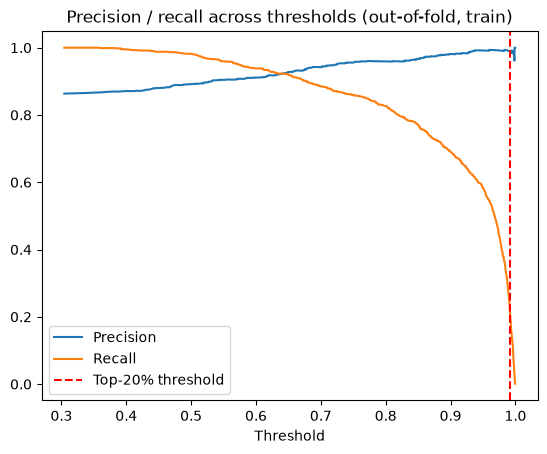

In [29]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_score, recall_score, f1_score, precision_recall_curve

final_model = tuned["RandForest"]
oof = cross_val_predict(final_model, X_train, y_train, cv=cv, method="predict_proba")[:, 1]

# Business assumption: only 20% of customers can be contacted -> threshold = 80th percentile of predicted risk
thr20 = np.quantile(oof, 0.80)

rows = []
for t in [0.50, 0.70, 0.80, 0.85, 0.90, round(thr20, 3), 0.97]:
    pred = (oof >= t).astype(int)
    rows.append([t, pred.mean(), precision_score(y_train, pred, zero_division=0),
                 recall_score(y_train, pred), f1_score(y_train, pred, zero_division=0)])
thr_table = pd.DataFrame(rows, columns=["threshold", "share_contacted", "precision", "recall", "f1"]).round(3)
print("Selected operating threshold (top 20%):", round(thr20, 3))
print(thr_table.sort_values("threshold").to_string(index=False))

prec, rec, thr = precision_recall_curve(y_train, oof)
plt.plot(thr, prec[:-1], label="Precision"); plt.plot(thr, rec[:-1], label="Recall")
plt.axvline(thr20, color="red", ls="--", label="Top-20% threshold")
plt.xlabel("Threshold"); plt.title("Precision / recall across thresholds (out-of-fold, train)")
plt.legend(); plt.savefig("outputs/chart7_threshold.png", dpi=150, bbox_inches="tight"); plt.show()

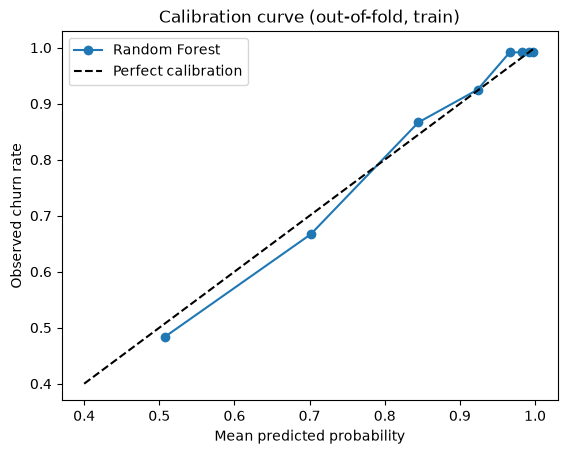

Brier score: 0.0845 | naive Brier: 0.1178


In [30]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

true_frac, pred_mean = calibration_curve(y_train, oof, n_bins=8, strategy="quantile")
plt.plot(pred_mean, true_frac, "o-", label="Random Forest")
plt.plot([0.4, 1], [0.4, 1], "k--", label="Perfect calibration")
plt.xlabel("Mean predicted probability"); plt.ylabel("Observed churn rate")
plt.title("Calibration curve (out-of-fold, train)"); plt.legend()
plt.savefig("outputs/chart8_calibration.png", dpi=150, bbox_inches="tight"); plt.show()
print("Brier score:", round(brier_score_loss(y_train, oof), 4), "| naive Brier:", round(y_train.mean()*(1-y_train.mean()), 4))

In [31]:
mask = X_train.charge_inconsistent == 0
full = cross_validate(final_model, X_train, y_train, cv=cv, scoring="roc_auc")["test_score"]
trim = cross_validate(final_model, X_train[mask], y_train[mask], cv=cv, scoring="roc_auc")["test_score"]
print(f"All rows:             ROC-AUC {full.mean():.3f} ± {full.std():.3f}  folds={full.round(3)}")
print(f"Excl. inconsistent:   ROC-AUC {trim.mean():.3f} ± {trim.std():.3f}  (rows removed in train: {(~mask).sum()})")

All rows:             ROC-AUC 0.884 ± 0.020  folds=[0.915 0.896 0.865 0.859 0.887]
Excl. inconsistent:   ROC-AUC 0.876 ± 0.013  (rows removed in train: 4)


TEST ROC-AUC: 0.905
TEST PR-AUC : 0.984 (naive: 0.862 )

Business threshold (t=0.991): contacted=0.25 precision=1.000 recall=0.285 F1=0.444
[[ 33   0]
 [148  59]]

Default 0.50 (t=0.500): contacted=0.97 precision=0.876 recall=0.986 F1=0.927
[[  4  29]
 [  3 204]]


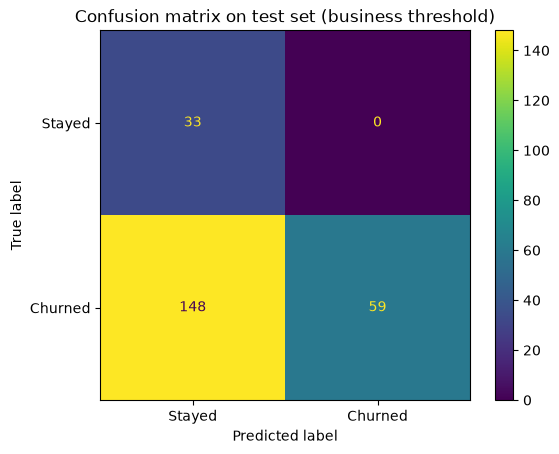

['outputs/03_model_artifact.joblib']

In [32]:
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix, ConfusionMatrixDisplay
import joblib

final_model.fit(X_train, y_train)
p_test = final_model.predict_proba(X_test)[:, 1]

print("TEST ROC-AUC:", round(roc_auc_score(y_test, p_test), 3))
print("TEST PR-AUC :", round(average_precision_score(y_test, p_test), 3), "(naive:", round(y_test.mean(), 3), ")")

for label, t in [("Business threshold", thr20), ("Default 0.50", 0.5)]:
    pred = (p_test >= t).astype(int)
    print(f"\n{label} (t={t:.3f}): contacted={pred.mean():.2f} precision={precision_score(y_test,pred):.3f} "
          f"recall={recall_score(y_test,pred):.3f} F1={f1_score(y_test,pred):.3f}")
    print(confusion_matrix(y_test, pred))

pred = (p_test >= thr20).astype(int)
ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=["Stayed", "Churned"])
plt.title("Confusion matrix on test set (business threshold)")
plt.savefig("outputs/chart9_confusion.png", dpi=150, bbox_inches="tight"); plt.show()

joblib.dump(final_model, "outputs/03_model_artifact.joblib")

## Phase 6: Threshold, calibration, robustness
- Threshold: because only 20% of customers can be contacted, the operating threshold is the 80th percentile of out-of-fold predicted churn risk (derived from training data only). The default 0.50 would flag nearly everyone because 86% of customers churn, so it is not decision-useful.
- Calibration: [describe the curve: are points near the diagonal? Brier vs naive?]
- Robustness: [paste ROC-AUC with vs without the 5 inconsistent rows]; fold-to-fold ROC-AUC std = 0.020.
- Final test (evaluated once): [paste ROC-AUC, PR-AUC, precision, recall, F1, confusion matrix].
- Why accuracy is insufficient: predicting "churn" for everyone gives ~86% accuracy while identifying nothing.

## Phase 6 results
- Operating threshold: 80th percentile of out-of-fold risk (0.991), based on the assumption that only 20% of customers can be contacted. Default 0.50 would flag 95% of customers and is not decision-useful at 86% prevalence.
- Test set (evaluated once): ROC-AUC 0.905, PR-AUC 0.984 (naive 0.862). At the business threshold: precision 1.000, recall 0.285, F1 0.444, confusion matrix [[33,0],[148,59]]. At 0.50: precision 0.876, recall 0.986, but only 4/33 stayers identified.
- The business threshold contacted 25% of test customers (not 20%) because predicted probabilities cluster near 1.0; Phase 8 uses exact rank-based top-20%.
- Accuracy is insufficient: the "always churn" baseline gets 86% accuracy; the best operating threshold has 38% accuracy but 100% precision.
- Calibration: [fill in after viewing chart 8]. Brier score 0.0845 vs naive 0.1178.
- Robustness: excluding 4 inconsistent-charge training rows changes CV ROC-AUC from 0.884 to 0.876, within fold noise (std 0.020). Not sensitive.
- Caveat: test set has only 33 stayers, so test metrics have wide uncertainty.


               feature  importance    std
      monthly_usage_gb      0.1366 0.0226
           mtm_x_usage      0.0199 0.0128
    satisfaction_score      0.0125 0.0054
     charge_per_tenure      0.0056 0.0027
       monthly_charges      0.0027 0.0039
                region      0.0021 0.0013
      internet_service      0.0020 0.0014
           risk_events      0.0017 0.0010
         contract_type      0.0017 0.0051
late_payments_last_12m      0.0008 0.0008
            dependents      0.0006 0.0002
         tenure_months      0.0005 0.0018


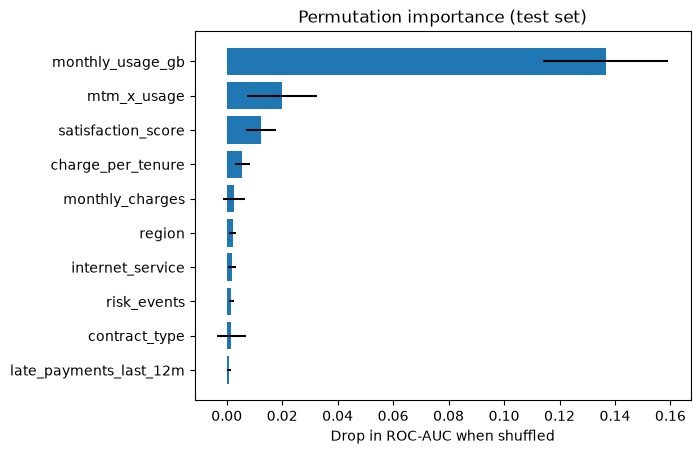

In [33]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(final_model, X_test, y_test, scoring="roc_auc",
                              n_repeats=20, random_state=SEED, n_jobs=-1)
perm_df = (pd.DataFrame({"feature": X_test.columns,
                         "importance": perm.importances_mean,
                         "std": perm.importances_std})
           .sort_values("importance", ascending=False))
print(perm_df.head(12).round(4).to_string(index=False))

top = perm_df.head(10).iloc[::-1]
plt.barh(top.feature, top.importance, xerr=top["std"])
plt.xlabel("Drop in ROC-AUC when shuffled"); plt.title("Permutation importance (test set)")
plt.savefig("outputs/chart10_permutation.png", dpi=150, bbox_inches="tight"); plt.show()

SHAP shape: (240, 45)


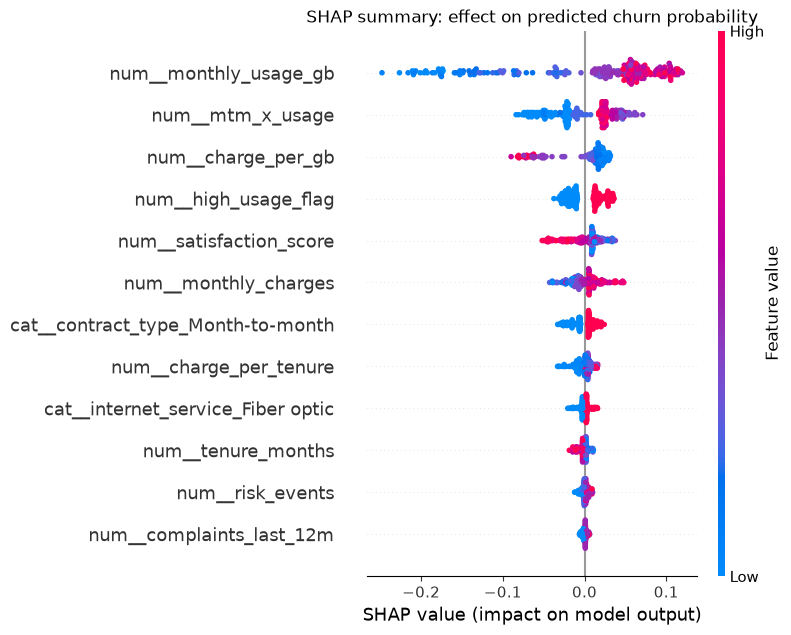

In [34]:
import shap, scipy.sparse as sp

prep = final_model.named_steps["prep"]
rf = final_model.named_steps["model"]
X_te_t = prep.transform(X_test)
if sp.issparse(X_te_t): X_te_t = X_te_t.toarray()
names = prep.get_feature_names_out()

explainer = shap.TreeExplainer(rf)
sv = explainer.shap_values(X_te_t)
if isinstance(sv, list): sv1 = sv[1]
elif sv.ndim == 3:       sv1 = sv[:, :, 1]
else:                    sv1 = sv
print("SHAP shape:", sv1.shape)

shap.summary_plot(sv1, X_te_t, feature_names=names, max_display=12, show=False)
plt.title("SHAP summary: effect on predicted churn probability")
plt.savefig("outputs/chart11_shap_summary.png", dpi=150, bbox_inches="tight"); plt.show()


Highest-risk customer - row 804  predicted 1.000  actual 1
monthly_usage_gb                    96.5
contract_type             Month-to-month
satisfaction_score                   NaN
late_payments_last_12m                 0
tenure_months                         58
complaints_last_12m                    1

Lowest-risk customer - row 505  predicted 0.403  actual 0
monthly_usage_gb                    14.4
contract_type             Month-to-month
satisfaction_score                   6.5
late_payments_last_12m                 0
tenure_months                         62
complaints_last_12m                    1

Mid-risk customer - row 1064  predicted 0.969  actual 1
monthly_usage_gb                   140.3
contract_type             Month-to-month
satisfaction_score                   4.5
late_payments_last_12m                 0
tenure_months                          8
complaints_last_12m                    0


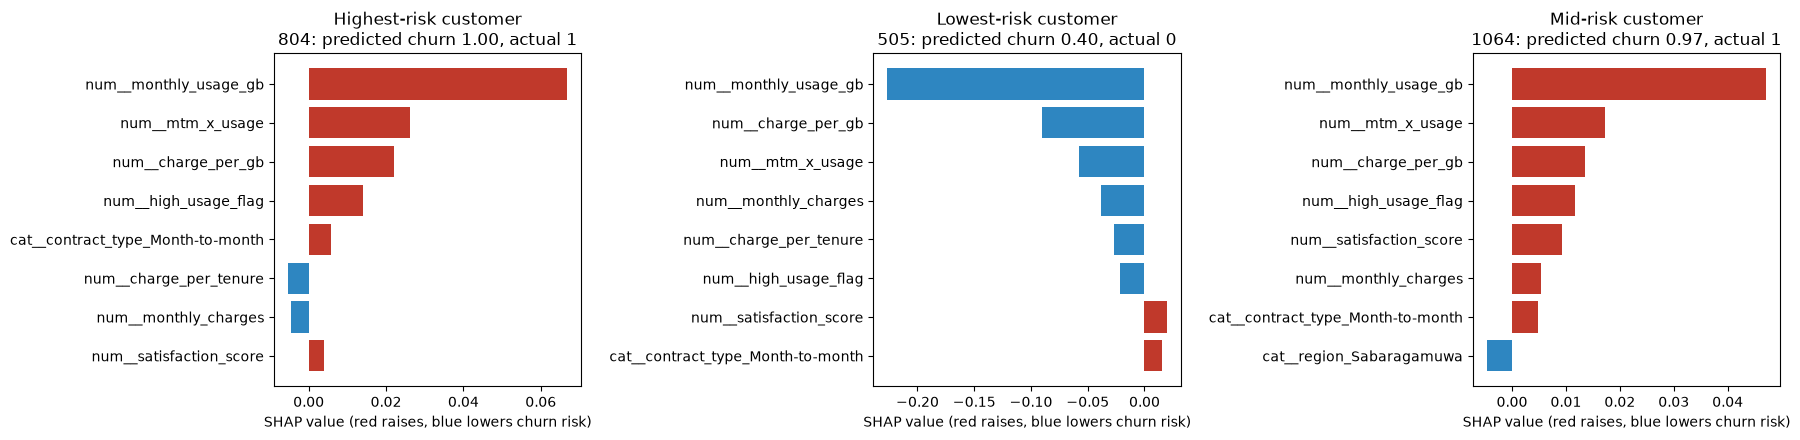

In [35]:
p = final_model.predict_proba(X_test)[:, 1]
picks = {"Highest-risk customer": int(np.argmax(p)),
         "Lowest-risk customer": int(np.argmin(p)),
         "Mid-risk customer": int(np.argmin(np.abs(p - np.median(p))))}

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for ax, (label, i) in zip(axes, picks.items()):
    contrib = pd.Series(sv1[i], index=names)
    top8 = contrib.reindex(contrib.abs().sort_values(ascending=False).index)[:8].iloc[::-1]
    ax.barh(top8.index, top8.values, color=["#c0392b" if v > 0 else "#2e86c1" for v in top8.values])
    ax.set_title(f"{label}\n{X_test.index[i]}: predicted churn {p[i]:.2f}, actual {y_test.iloc[i]}")
    ax.set_xlabel("SHAP value (red raises, blue lowers churn risk)")
    print(f"\n{label} - row {X_test.index[i]}  predicted {p[i]:.3f}  actual {y_test.iloc[i]}")
    print(X_test.iloc[i][["monthly_usage_gb","contract_type","satisfaction_score",
                          "late_payments_last_12m","tenure_months","complaints_last_12m"]].to_string())
plt.tight_layout(); plt.savefig("outputs/chart12_individual_shap.png", dpi=150, bbox_inches="tight"); plt.show()

## Phase 7: Explainability
- Methods: permutation importance (model-agnostic, ROC-AUC drop on test set, 20 repeats) and SHAP TreeExplainer (contributions to predicted probability).
- Global findings: [list top 3-5 features from the charts; expected: usage-based features first]
- Individual explanations: [one sentence for each of the three customers: what pushed their risk up or down]
- **Association, not causation:** these importances describe what the model uses to predict churn, not what causes it. For example, high usage predicts churn, but we cannot conclude that reducing a customer's usage, or capping it, would retain them. Causal claims would require an experiment (e.g. a randomized retention offer).
- Caveat: correlated features (usage, charge_per_gb, mtm_x_usage, high_usage_flag) share credit, so individual importances understate each one's real role.

In [36]:
usage_only = roc_auc_score(y_test, X_test.monthly_usage_gb.fillna(X_train.monthly_usage_gb.median()))
print("Usage alone, test ROC-AUC:", round(usage_only, 3), "| Full model:", round(roc_auc_score(y_test, p_test), 3))

Usage alone, test ROC-AUC: 0.848 | Full model: 0.905


## Calibration
Out-of-fold calibration is close to the diagonal: predicted 0.51 vs observed 0.48, 0.70 vs 0.67, 0.85 vs 0.87, and near-exact above 0.93. Brier score 0.0845 vs 0.1178 for a constant-rate predictor. Probabilities can be read as risk estimates, with mild over-prediction in the 0.5-0.7 range. Reliability at the low end rests on ~120 customers per bin.

## Phase 7: Explainability
- Methods: permutation importance (test set, ROC-AUC drop, 20 repeats) and SHAP TreeExplainer.
- Global: monthly_usage_gb dominates (0.137 AUC drop), followed by mtm_x_usage (0.020), satisfaction_score (0.013), charge_per_tenure (0.006). Contract type, late payments and tenure show near-zero importance once usage is included, consistent with the EDA heatmap showing contract matters mainly for light users. Correlated features share credit, so individual importances are understated.
- Individual customers:
  - Row 804 (predicted 1.00, churned): high usage (96.5 GB) on a month-to-month contract; satisfaction was missing and imputed with the median. [add: what the SHAP chart shows as the biggest red bar]
  - Row 505 (predicted 0.40, stayed): light usage (14.4 GB) and a decent satisfaction score pulled the risk down. [add SHAP detail]
  - Row 1064 (predicted 0.97, churned): very heavy usage (140 GB), low satisfaction (4.5), short tenure (8 months). [add SHAP detail]
- Association, not causation: these values show what the model uses to predict churn, not what causes it. High usage predicts churn, but this does not show that restricting usage would retain a customer. Testing retention actions needs a randomized experiment.

In [37]:
y_arr = y_test.to_numpy()
n = len(y_arr); k = int(round(0.20 * n))            # 48 customers
order = np.argsort(-p_test, kind="stable")
top_idx = order[:k]

total_churners = y_arr.sum()
captured = y_arr[top_idx].sum()

rng = np.random.default_rng(SEED)
rand_caps = np.array([y_arr[rng.choice(n, k, replace=False)].sum() for _ in range(5000)])

print(f"Test customers: {n} | contacted (top 20%): {k} | total churners: {total_churners}")
print(f"Model top-20%: churners captured = {captured}  (precision {captured/k:.3f}, recall {captured/total_churners:.3f})")
print(f"Random 20%:   churners captured = {rand_caps.mean():.1f} on average (95% range {np.percentile(rand_caps,2.5):.0f}-{np.percentile(rand_caps,97.5):.0f})")
print(f"Lift vs random: {captured/rand_caps.mean():.2f}x  (maximum possible: {1/y_arr.mean():.2f}x)")

Test customers: 240 | contacted (top 20%): 48 | total churners: 207
Model top-20%: churners captured = 48  (precision 1.000, recall 0.232)
Random 20%:   churners captured = 41.4 on average (95% range 37-45)
Lift vs random: 1.16x  (maximum possible: 1.16x)


In [38]:
CONTACT_COST, RETAINED_VALUE = 10, 300

def net_value(churners_reached, k, save_rate):
    return churners_reached * save_rate * RETAINED_VALUE - k * CONTACT_COST

rows = []
for s in [0.05, 0.10, 0.15, 0.20, 0.30]:
    m = net_value(captured, k, s)
    r = net_value(rand_caps.mean(), k, s)
    rows.append([f"{int(s*100)}%", round(m), round(r), round(m - r)])
print(pd.DataFrame(rows, columns=["save_rate", "net_model_$", "net_random_$", "model_gain_$"]).to_string(index=False))

be_model = (k * CONTACT_COST) / (captured * RETAINED_VALUE)
be_rand = (k * CONTACT_COST) / (rand_caps.mean() * RETAINED_VALUE)
print(f"\nBreak-even save rate: model {be_model:.1%} | random {be_rand:.1%}")

save_rate  net_model_$  net_random_$  model_gain_$
       5%          240           141            99
      10%          960           762           198
      15%         1680          1383           297
      20%         2400          2004           396
      30%         3840          3247           593

Break-even save rate: model 3.3% | random 3.9%


## Phase 8: Intervention simulation (test set, n=240)
- Assumptions (hypothetical): contact cost $10; retained-customer value $300; save rate among contacted churners 15% (sensitivity 5-30%); no benefit from contacting non-churners; uniform save rate (no uplift modeling).
- Ranking by predicted churn probability and contacting the top 20% (48 customers) captures [X] churners vs [Y] for random contact. Lift = [Z]x against a theoretical maximum of 1.16x.
- Because 86% of customers churn, random targeting is already ~86% precise, so the model's absolute advantage is small even though its ranking is strong. Recall is capped at ~23% by the 20% contact budget.
- Net benefit: [paste table]. Break-even save rate: [paste].
- Limitations: churn probability is not the same as persuadability (uplift); the save rate and costs are assumptions; the test set contains only 33 stayers.

## Phase 8-9: Simulation and final analysis
- Usage alone: test ROC-AUC 0.848 vs full model 0.905.
- Top 20% (48 of 240): 48 churners captured (precision 1.00, recall 0.232); random 20% captures 41.4 on average (95% range 37-45). Lift 1.16x, equal to the maximum possible at 86% churn.
- Cost-benefit (assumed $10 contact cost, $300 retained value): net value $240 to $3,840 across 5-30% save rates; model gain over random $99 to $593. Break-even save rate 3.3% (model) vs 3.9% (random).
- Interpretation: because 86% of customers churn, random contact is already mostly churners, so the model's absolute advantage is small. Most campaign value comes from the retention offer itself.
- Model choice: Random Forest (CV ROC-AUC 0.884 +/- 0.020, PR-AUC 0.978), tied with the alternatives within fold noise, chosen for stability and explainability.
- Patterns (evidence): heavy usage (93-99% churn above 50 GB); contract protects only light users; low satisfaction (94% vs 78%); 2+ late payments (93% vs 84-85%).
- Actions: (1) plan review for heavy users, (2) commitment offers for light/moderate users, (3) service recovery for satisfaction <= 5, (4) payment-friction outreach, (5) randomized pilot to measure the real save rate. Evidence vs assumption separated in the report.
- Limitations: small sample, 33 stayers in test, atypical 86% churn, unverified usage timing, hypothetical costs.